In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [3]:
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, classification_report, confusion_matrix, auc

In [4]:
#load the dataset

df = pd.read_csv('/kaggle/input/jigsaw-toxic-comment-classification-challenge/train.csv')

In [5]:
df.shape

(159571, 8)

In [6]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [7]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [9]:
##EDA
x = df.iloc[:, 2:] #only the labels

In [10]:
x.sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [11]:
rowsums = x.sum(axis=1)

In [12]:
rowsums

0         0
1         0
2         0
3         0
4         0
         ..
159566    0
159567    0
159568    0
159569    0
159570    0
Length: 159571, dtype: int64

In [13]:
no_label_count = 0

for i, count in rowsums.items():
    if count==0:
        no_label_count += 1
print("total number of comments without labels: ", no_label_count)

total number of comments without labels:  143346


In [14]:
print("total number of comments: ", len(df))

total number of comments:  159571


In [15]:
x.sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [16]:
x.sum().sum()

35098

In [17]:
len(df) - x.sum().sum() #total number of comments - total number of labels

124473

In [18]:
#124473 NOT EQUAL TO 143346, so it means a single comment can have multiple labels and thus it is multilabel classification and not multiclass classification

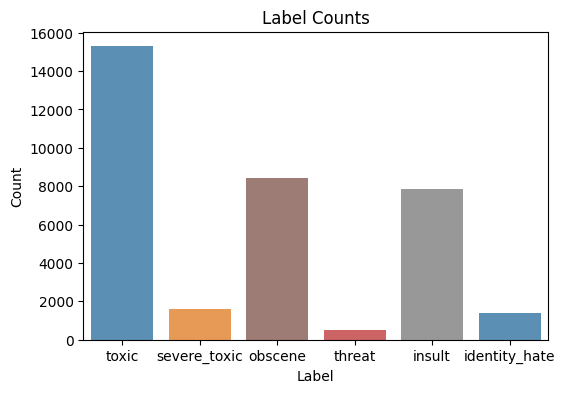

In [19]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=x.sum().index, y=x.sum().values, alpha=0.8, palette=['tab:blue', 'tab:orange', 'tab:brown', 'tab:red', 'tab:grey'])
plt.title('Label Counts')
plt.ylabel('Count')
plt.xlabel('Label')
plt.show()

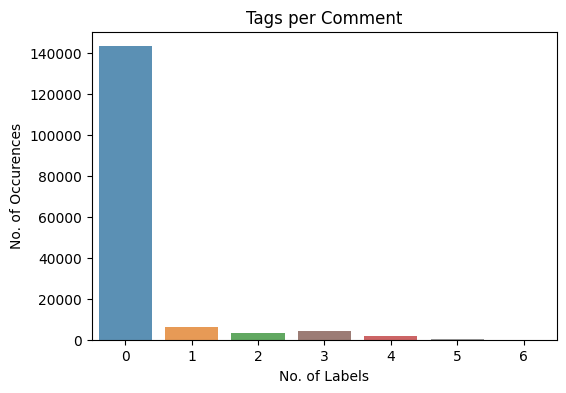

In [20]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=rowsums.values, alpha=0.8, palette=['tab:blue', 'tab:orange', 'tab:green', 'tab:brown', 'tab:red', 'tab:grey'])
plt.title('Tags per Comment')
plt.ylabel('No. of Occurences')
plt.xlabel('No. of Labels')
plt.show()

In [21]:
df = df.drop(columns=['id'], axis=1)

In [22]:
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [23]:
from nltk.corpus import stopwords

#define stopwords correctly
stop_words_set = set(stopwords.words('english'))

def remove_stopwords(text):
    no_stopword_text = [w for w in text.split() if w not in stop_words_set]
    return " ".join(no_stopword_text)

In [24]:
print(remove_stopwords("kashish is a good girl"))

kashish good girl


In [25]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)
    text = re.sub('\W', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip(' ')
    
    return text

In [26]:
clean_text("what's wrong with you")

'what is wrong with you'

In [27]:
# stemming
stemmer = SnowballStemmer('english')

def stem(sentence):
    stemmed_sentence = ""
    for word in sentence.split():
        stemmed_word = stemmer.stem(word)
        stemmed_sentence += stemmed_word + " "
        
    stemmed_sentence = stemmed_sentence.strip()
    return stemmed_sentence

In [28]:
stem("what is the red haired girl even doing here?")

'what is the red hair girl even do here?'

In [29]:
#applyy

df['comment_text'] = df['comment_text'].apply(lambda x: remove_stopwords(x))
df['comment_text'] = df['comment_text'].apply(lambda x: clean_text(x))
df['comment_text'] = df['comment_text'].apply(lambda x: stem(x))

In [30]:
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explan whi edit made usernam hardcor metallica...,0,0,0,0,0,0
1,d aww he match background colour i am seem stu...,0,0,0,0,0,0
2,hey man i am realli tri edit war it guy consta...,0,0,0,0,0,0
3,more i can not make real suggest improv i wond...,0,0,0,0,0,0
4,you sir hero ani chanc rememb page that on,0,0,0,0,0,0


In [31]:
#i/p o/p splitt

X = df['comment_text']
y = df.drop(columns=['comment_text'], axis=1)

In [32]:
y.shape

(159571, 6)

In [33]:
X.shape

(159571,)

In [34]:
# split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
def run_pipeline(pipeline, X_train, X_test, y_train, y_test):
    #train the model
    pipeline.fit(X_train, y_train)
    
    #predict labels and probabilities
    predictions = pipeline.predict(X_test)
    pred_probs = pipeline.predict_proba(X_test)  # for ROC AUC, adjust this for binary/multi-label
    
    #print metrics
    print('roc_auc:', roc_auc_score(y_test, pred_probs, average='macro'))  #for multi-label, use `average='macro'`
    print('accuracy:', accuracy_score(y_test, predictions))
    print('classification report')
    print(classification_report(y_test, predictions))
    
    #plot the ROC Curve
    plt.figure(figsize=(10, 6))
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:  #multi-label/multi-class case
        for i in range(y_test.shape[1]):
            fpr, tpr, _ = roc_curve(y_test.iloc[:, i], pred_probs[:, i])
            plt.plot(fpr, tpr, label=f'Class {y_train.columns[i]} (AUC = {auc(fpr, tpr):.2f})')
    else:  # Binary case
        fpr, tpr, _ = roc_curve(y_test, pred_probs[:, 1])  #assuming positive class is index 1
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc(fpr, tpr):.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='best')
    plt.show()
    
    #plot the Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test.values.argmax(axis=1), predictions.argmax(axis=1))  # Adjust for multi-label if needed
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_train.columns, yticklabels=y_train.columns)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

In [36]:
"""
Step 1: tfidf converts the input text data into TF-IDF vectors.
Step 2: nb_model applies Multinomial Naive Bayes as the classifier. 
The OvR wrapper allows it to handle multiple labels or classes by training a separate classifier for each class.
"""

Naive_bayes_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb_model', OneVsRestClassifier(MultinomialNB(), n_jobs=-1))
])

In [37]:
"""
Step 1: tfidf performs the same TF-IDF transformation as in NB_pipeline.
Step 2: nb_model here is Logistic Regression, again wrapped in OvR to support multi-label or multi-class tasks.
"""

Logistic_regression_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb_model', OneVsRestClassifier(LogisticRegression(), n_jobs=-1))
])


roc_auc: 0.8604178106899295
accuracy: 0.8997963340122199
classification report
              precision    recall  f1-score   support

           0       0.99      0.19      0.32      3056
           1       0.00      0.00      0.00       321
           2       0.98      0.11      0.20      1715
           3       1.00      0.01      0.03        74
           4       0.97      0.05      0.10      1614
           5       0.00      0.00      0.00       294

   micro avg       0.98      0.12      0.22      7074
   macro avg       0.66      0.06      0.11      7074
weighted avg       0.90      0.12      0.21      7074
 samples avg       0.02      0.01      0.01      7074



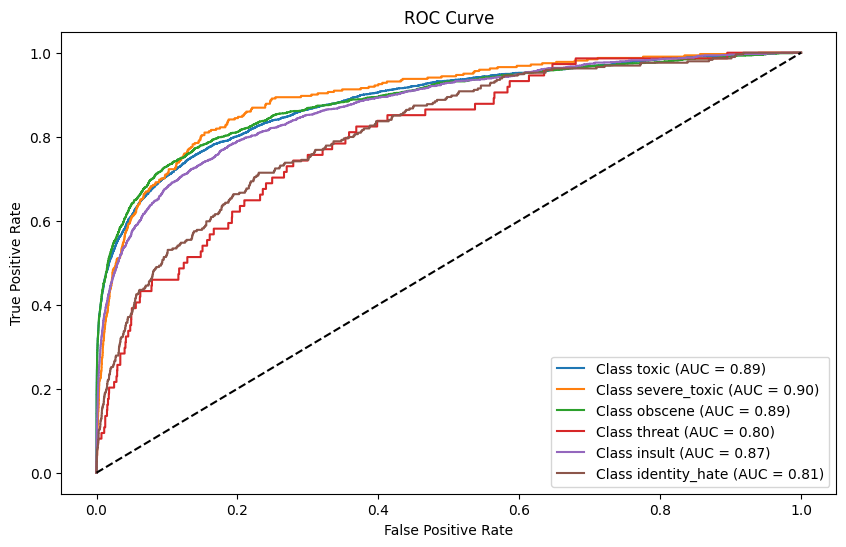

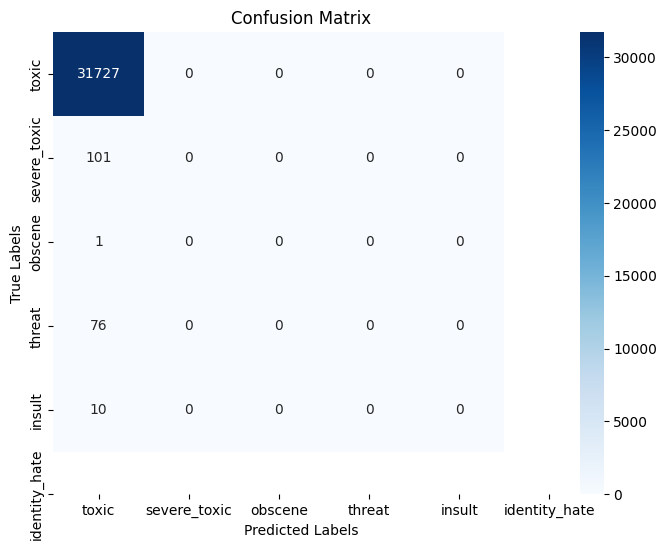

In [38]:
run_pipeline(Naive_bayes_pipeline, X_train, X_test, y_train, y_test)

roc_auc: 0.9794842342013226
accuracy: 0.9187216042613191
classification report
              precision    recall  f1-score   support

           0       0.91      0.62      0.74      3056
           1       0.58      0.28      0.38       321
           2       0.92      0.64      0.75      1715
           3       0.69      0.15      0.24        74
           4       0.81      0.51      0.62      1614
           5       0.72      0.16      0.26       294

   micro avg       0.88      0.56      0.68      7074
   macro avg       0.77      0.39      0.50      7074
weighted avg       0.87      0.56      0.67      7074
 samples avg       0.06      0.05      0.05      7074



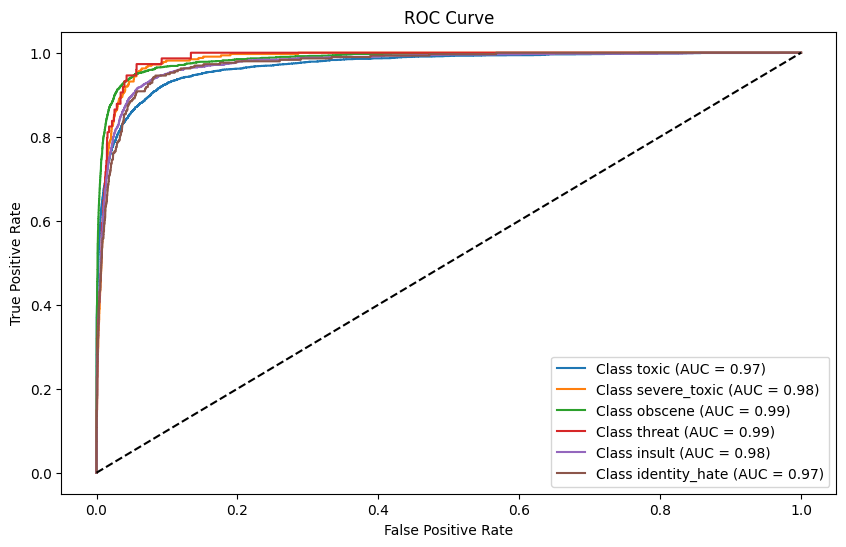

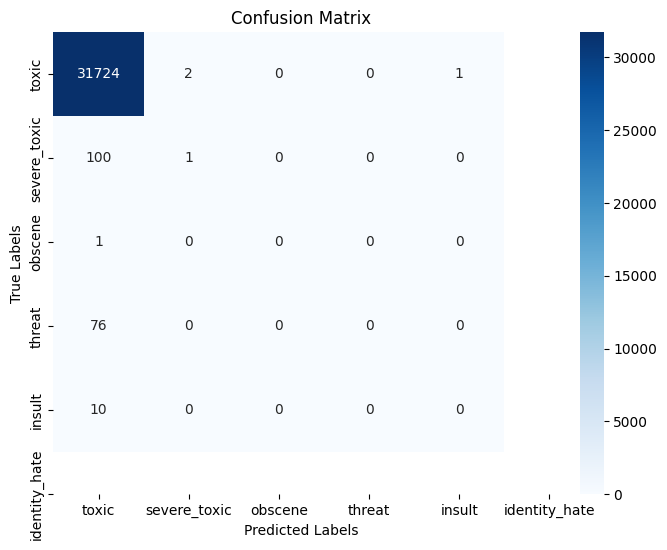

In [39]:
run_pipeline(Logistic_regression_pipeline, X_train, X_test, y_train, y_test)

In [40]:
##predictions - 6 classes

labels = y_train.columns.values
labels

array(['toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'], dtype=object)

In [41]:
X_test.head()

119105    geez forget we have alreadi discuss marx anarc...
131631    carioca rfa thank support request adminship th...
125326           birthday no worri it i enjoy ur day talk e
111256    pseudosci categori i am assum articl pseudosci...
83590     and phrase exist would provid search engin eve...
Name: comment_text, dtype: object

In [42]:
X_test.head().values

array(['geez forget we have alreadi discuss marx anarchist i e want use state mold ocialist man ergo statist opposit anarchist i know guy say that get old teeth fall out he will quit eat meat would call vegetarian',
       'carioca rfa thank support request adminship the final outcom 31 4 1 i administr if comment concern action administr pleas let know thank you',
       'birthday no worri it i enjoy ur day talk e',
       'pseudosci categori i am assum articl pseudosci categori associ creation howev modern scientif accept variant catastroph noth creation they are even mention articl i think connect pseudosci need clarifi articl made general less creation specif categori tag remov entir',
       'and phrase exist would provid search engin even mention page avail whole'],
      dtype=object)

In [43]:
X_test.sample(1).values[0]

'after origin afd someon ask restor draft it locat draft 1p lsd pleas feel free work there if articl brought state deal issu led decis delet it move articl space submit wp afc process edgar181'

In [44]:
sent = 'foil fulli support mani thank award well kiril'

results = Logistic_regression_pipeline.predict([sent])[0]
for label, result in zip(labels, results):
    print("%14s %5s" % (label, result))

         toxic     0
  severe_toxic     0
       obscene     0
        threat     0
        insult     0
 identity_hate     0


In [45]:
results = Naive_bayes_pipeline.predict([sent])[0]
for label, result in zip(labels, results):
    print("%14s %5s" % (label, result))

         toxic     0
  severe_toxic     0
       obscene     0
        threat     0
        insult     0
 identity_hate     0


In [46]:
sent2 = 'you fucking bitch, go die'

sent2 = stem(clean_text(remove_stopwords(sent2)))

In [47]:
sent2

'fuck bitch go die'

In [48]:
results2 = Logistic_regression_pipeline.predict([sent2])[0]
for label, result in zip(labels, results2):
    print("%14s %5s" % (label, result))

         toxic     1
  severe_toxic     1
       obscene     1
        threat     1
        insult     1
 identity_hate     0


In [49]:
results2 = Naive_bayes_pipeline.predict([sent2])[0]
for label, result in zip(labels, results2):
    print("%14s %5s" % (label, result))

         toxic     1
  severe_toxic     0
       obscene     1
        threat     0
        insult     1
 identity_hate     0


In [50]:
sent3 = 'kashish is a good girl'

sent3 = stem(clean_text(remove_stopwords(sent3)))

In [51]:
sent3

'kashish good girl'

In [52]:
results3 = Logistic_regression_pipeline.predict([sent3])[0]
for label, result in zip(labels, results3):
    print("%14s %5s" % (label, result))

         toxic     0
  severe_toxic     0
       obscene     0
        threat     0
        insult     0
 identity_hate     0


In [53]:
results3 = Naive_bayes_pipeline.predict([sent3])[0]
for label, result in zip(labels, results3):
    print("%14s %5s" % (label, result))

         toxic     0
  severe_toxic     0
       obscene     0
        threat     0
        insult     0
 identity_hate     0
